# Strength Progression Visualization

This notebook plots daily strength curves for multiple approaches and player profiles based on `simulate_player_strength.py`.

- Training remains source-accurate.
- Strength formula parameters are tunable.
- Approaches A1..A20 are visualized.

In [2]:
# import and utility
import sys
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

# Auto-detect repo root by locating the simulation script file
def find_repo_root(marker="scripts/simulate_player_strength.py"):
    p = Path.cwd()
    while True:
        candidate = p / marker
        if candidate.exists():
            return str(p)
        if p.parent == p:
            raise FileNotFoundError(f"Could not find {marker} in parent paths from {Path.cwd()}")
        p = p.parent

repo_root = find_repo_root()
print(f"Repo root resolved to: {repo_root}")
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
print(f"sys.path[0]={sys.path[0]}")

from scripts.simulate_player_strength import simulate_player

# Define approaches (same as in report)
approaches = [
    {'name':'A1_rotating_default','fixed':False,'main':0.55,'bonus':0.25,'overall':0.20,'str_mult':1.0},
    {'name':'A2_fixed_default','fixed':True,'main':0.55,'bonus':0.25,'overall':0.20,'str_mult':1.0},
    {'name':'A3_fixed_1.2','fixed':True,'main':0.55,'bonus':0.25,'overall':0.20,'str_mult':1.2},
    {'name':'A4_fixed_1.4','fixed':True,'main':0.55,'bonus':0.25,'overall':0.20,'str_mult':1.4},
    {'name':'A5_fixed_high_main','fixed':True,'main':0.70,'bonus':0.20,'overall':0.10,'str_mult':1.0},
    {'name':'A6_fixed_high_main_1.2','fixed':True,'main':0.70,'bonus':0.20,'overall':0.10,'str_mult':1.2},
    {'name':'A7_fixed_high_main_1.4','fixed':True,'main':0.70,'bonus':0.20,'overall':0.10,'str_mult':1.4},
    {'name':'A8_rotating_soft','fixed':False,'main':0.45,'bonus':0.20,'overall':0.35,'str_mult':1.2},
    {'name':'A9_rotating_bonus_focus','fixed':False,'main':0.45,'bonus':0.40,'overall':0.15,'str_mult':1.1},
    {'name':'A10_fixed_all_high','fixed':True,'main':0.50,'bonus':0.30,'overall':0.20,'str_mult':1.2},
    {'name':'A11_fixed_minimal_overlap','fixed':True,'main':0.85,'bonus':0.10,'overall':0.05,'str_mult':1.0},
    {'name':'A12_fixed_low_main','fixed':True,'main':0.40,'bonus':0.30,'overall':0.30,'str_mult':1.0},
    {'name':'A13_rotating_reward','fixed':False,'main':0.55,'bonus':0.25,'overall':0.20,'str_mult':1.4},
    {'name':'A14_rotating_premium','fixed':False,'main':0.70,'bonus':0.20,'overall':0.10,'str_mult':1.5},
    {'name':'A15_fixed_capped','fixed':True,'main':0.80,'bonus':0.10,'overall':0.10,'str_mult':0.9},
    {'name':'A16_fixed_nonlinear','fixed':True,'main':0.65,'bonus':0.20,'overall':0.15,'str_mult':1.1},
    {'name':'A17_rotating_strengthonly','fixed':False,'main':0.55,'bonus':0.25,'overall':0.20,'str_mult':2.0},
    {'name':'A18_fixed_extreme','fixed':True,'main':0.85,'bonus':0.10,'overall':0.05,'str_mult':2.0},
    {'name':'A19_fixed_medium','fixed':True,'main':0.65,'bonus':0.20,'overall':0.15,'str_mult':1.5},
    {'name':'A20_rotating_small','fixed':False,'main':0.60,'bonus':0.20,'overall':0.20,'str_mult':1.3},
]

players = [
    {'label':'weak_youth','start_age':16,'talent':6,'position':'MID','training_center_level':12,'initial_fitness':80},
    {'label':'good_youth','start_age':16,'talent':8,'position':'MID','training_center_level':15,'initial_fitness':90},
    {'label':'elite_youth','start_age':18,'talent':10,'position':'FWD','training_center_level':20,'initial_fitness':100},
]

# collect data
rows=[]
for app in approaches:
    for p in players:
        sim = simulate_player(
            start_age=p["start_age"], talent=p["talent"], position=p["position"], initial_strength=None,
            training_center_level=p["training_center_level"], initial_fitness=p["initial_fitness"], max_age=32,
            days_per_year=30, use_scout_style=True, fixed_main_training=app["fixed"], gain_multiplier=1.0,
            strength_multiplier=app["str_mult"], main_weight=app["main"], bonus_weight=app["bonus"], overall_weight=app["overall"])
        for r in sim:
            rows.append({
                "approach":app["name"],
                "player":p["label"],
                "day":r.day_index,
                "age":r.age,
                "strength":r.strength,
            })
df=pd.DataFrame(rows)
print(df.head())


Repo root resolved to: /root/projekte/Goal-Tactics
sys.path[0]=/root/projekte/Goal-Tactics
              approach      player  day     age  strength
0  A1_rotating_default  weak_youth    0  16.000     53.71
1  A1_rotating_default  weak_youth    1  16.033     53.96
2  A1_rotating_default  weak_youth    2  16.067     54.47
3  A1_rotating_default  weak_youth    3  16.100     55.46
4  A1_rotating_default  weak_youth    4  16.133     55.71


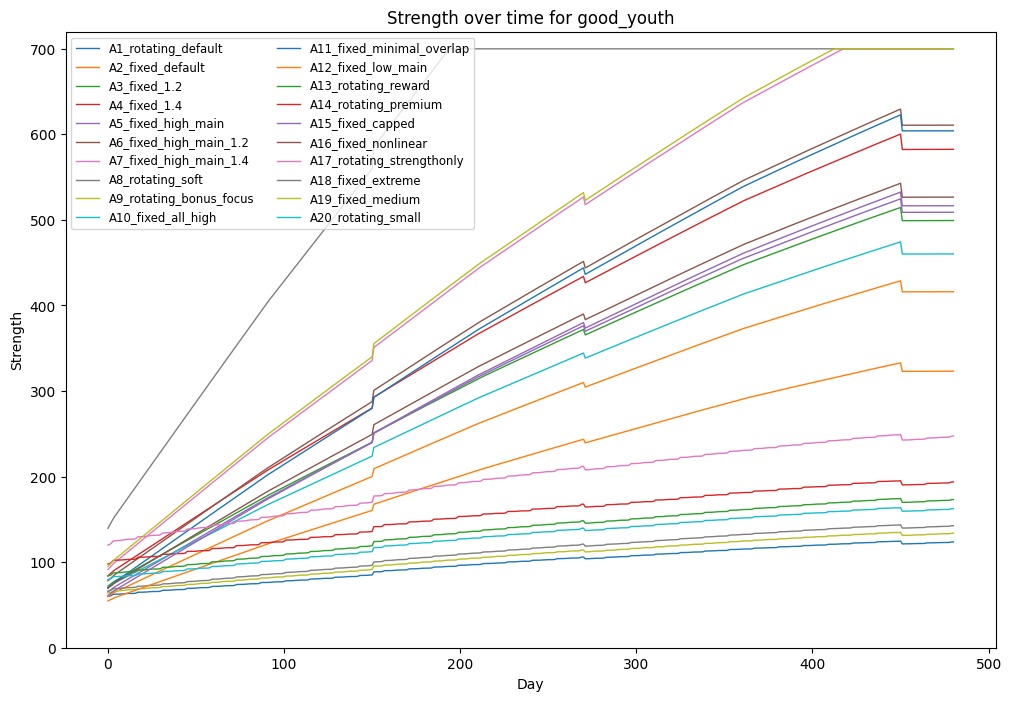

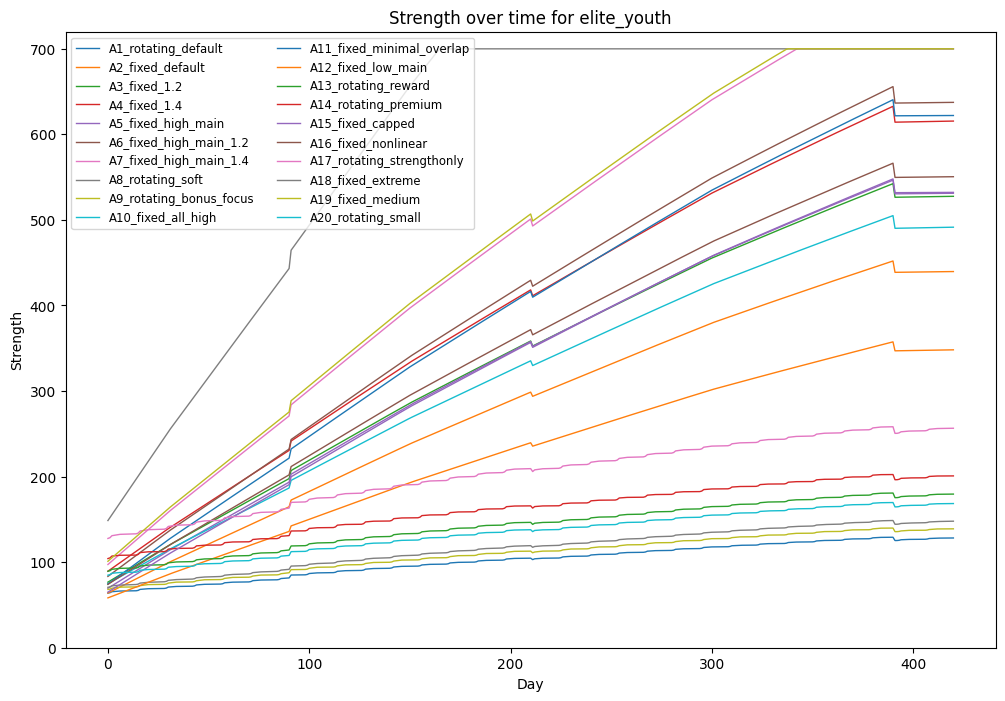

In [3]:
# plot per approach for good_youth and elite_youth
for player in ['good_youth', 'elite_youth']:
    fig, ax = plt.subplots(figsize=(12, 8))
    subset = df[df['player'] == player]
    for approach in subset['approach'].unique():
        curve = subset[subset['approach'] == approach]
        ax.plot(curve['day'], curve['strength'], label=approach, linewidth=1)
    ax.set_title(f"Strength over time for {player}")
    ax.set_xlabel('Day')
    ax.set_ylabel('Strength')
    ax.set_ylim(0, 720)
    ax.legend(fontsize='small', ncol=2)
    plt.show()

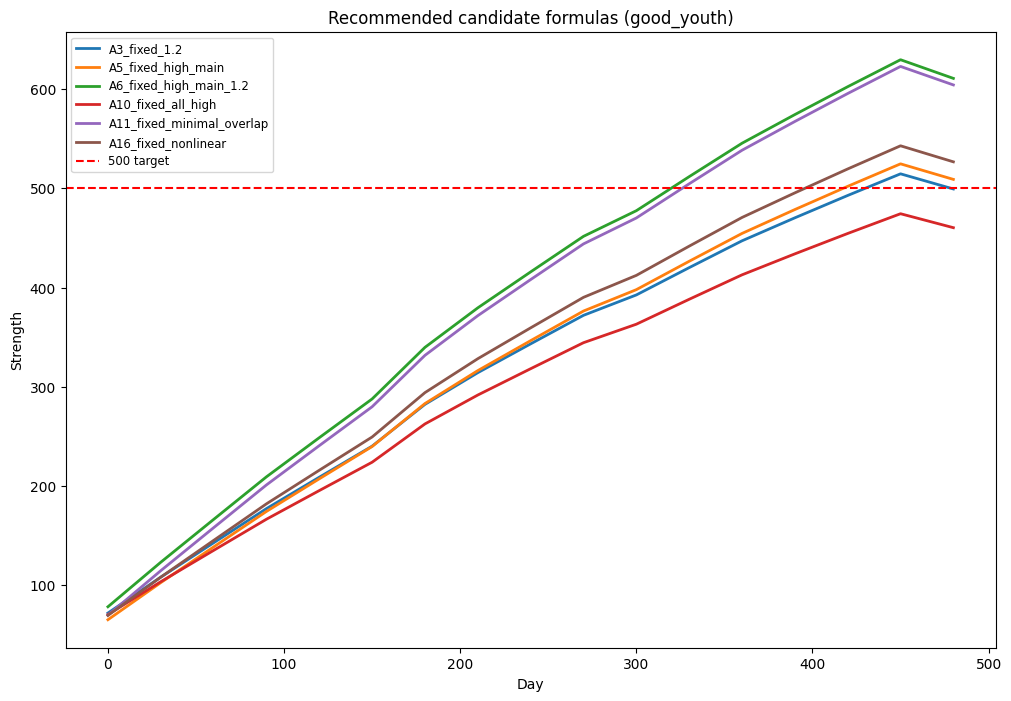

In [26]:
# Plot only recommended subset around 500@30 for clarity
recommended = ['A3_fixed_1.2','A5_fixed_high_main','A6_fixed_high_main_1.2','A10_fixed_all_high','A11_fixed_minimal_overlap','A16_fixed_nonlinear']
fig, ax = plt.subplots(figsize=(12, 8))
subset = df[(df['player']=='good_youth') & (df['approach'].isin(recommended))]
for approach in recommended:
    curve = subset[subset['approach']==approach]
    ax.plot(curve['day'], curve['strength'], label=approach, linewidth=2)
ax.set_title('Recommended candidate formulas (good_youth)')
ax.set_xlabel('Day')
ax.set_ylabel('Strength')
ax.axhline(500, color='red', linestyle='--', label='500 target')
ax.legend(fontsize='small')
plt.show()